# Eksplorujemy modele `speech-to-text`: `openai/whisper-1`

## Czym jest model `whisper-1`?
 
* Model `whisper-1` jest modelem do rozpoznawania mowy.
* Dostępny jest za pośrednictwem API OpenAI.
* Model ten jest w stanie rozpoznać mowę w wielu językach.
* Potrafi zwrócić cały tekst na raz lub pojedyncze słowa i zdania wraz z czasem ich wystąpienia.
* Wejście: nagranie audio
* Wyjście: tekst oraz opcjonalnie czas wystąpienia słów

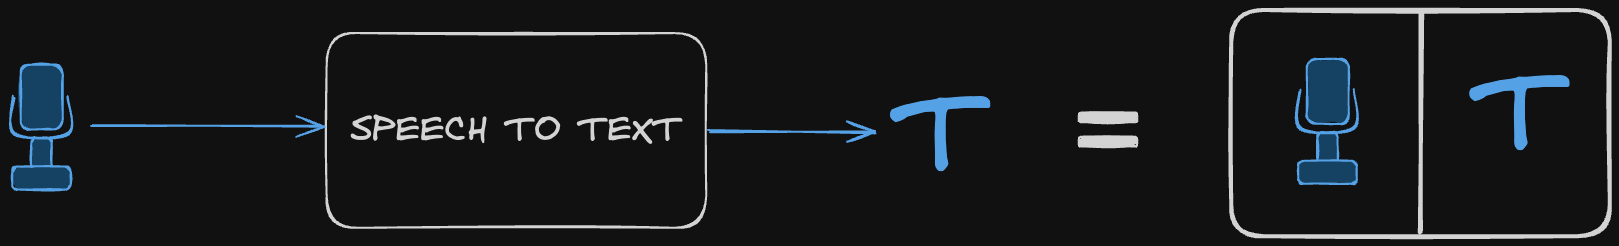

## Instalujemy wymagane biblioteki (conda wymagana)

- otwórz terminal
- uruchom `conda activate od_zera_do_ai`
- uruchom `conda install -y openai==1.47.0 python-dotenv`

In [1]:
from dotenv import dotenv_values
from IPython.display import Markdown
from openai import OpenAI

In [10]:
import os
os.getcwd()

'c:\\Python\\Python-lessons\\akademia\\notatki_glosowe\\audio_notes_v2'

In [13]:
env = dotenv_values("../../../.env")

openai_client = OpenAI(api_key=env["OPENAI_API_KEY"])

## Jak używać modelu `whisper-1` do rozpoznawania mowy?

In [14]:
with open("audio_about_ai.mp3", "rb") as f:
    transcript = openai_client.audio.transcriptions.create(
        file=f,
        model="whisper-1",
    )

In [15]:
Markdown(transcript.text)

Sztuczna inteligencja to dziedzina technologii, która umożliwia maszynom naśladowanie ludzkiego myślenia i podejmowanie decyzji. Dzięki zaawansowanym algorytmom i uczeniu maszynowemu, AI potrafi analizować ogromne ilości danych, rozpoznawać wzorce i przewidywać przyszłe zdarzenia. Współcześnie AI znajduje zastosowanie w wielu dziedzinach, takich jak medycyna, finanse, transport czy edukacja, rewolucjonizując sposób w jaki funkcjonuje społeczeństwo. Choć niesie ze sobą ogromny potencjał, rozwój AI rodzi także pytania o etykę, prywatność i przyszłość rynku pracy.

In [16]:
# sprawdźmy jak dobrze `whisper-1` poradził sobie z tekstem
with open("audio_about_ai.txt", "r") as f:
    print(f.read())


Sztuczna inteligencja to dziedzina technologii,
która umożliwia maszynom naśladowanie ludzkiego myślenia i podejmowania decyzji.

Dzięki zaawansowanym algorytmom i uczeniu maszynowemu, AI potrafi analizować ogromne ilości danych,
rozpoznawać wzorce i przewidywać przyszłe zdarzenia.

Współcześnie AI znajduje zastosowanie w wielu dziedzinach, takich jak medycyna, finanse,
transport czy edukacja, rewolucjonizując sposób, w jaki funkcjonują społeczeństwa.

Choć niesie ze sobą ogromny potencjał, rozwój AI rodzi także pytania o etykę,
prywatność i przyszłość rynku pracy.



## Jak używać modelu `whisper-1` do rozpoznania języka mówionego?

In [17]:
with open("audio_about_ai.mp3", "rb") as f:
    transcript = openai_client.audio.transcriptions.create(
        file=f,
        model="whisper-1",
        response_format="verbose_json",
    )

In [18]:
transcript.language

'polish'

## Jak używać modelu `whisper-1` do detekcji wystąpień słów?

In [19]:
with open("audio_about_ai.mp3", "rb") as f:
    transcript = openai_client.audio.transcriptions.create(
        file=f,
        model="whisper-1",
        response_format="verbose_json",
        timestamp_granularities=["word", "segment"],
    )

In [20]:
transcript.words

[TranscriptionWord(end=1.440000057220459, start=0.0, word='Sztuczna'),
 TranscriptionWord(end=2.0199999809265137, start=1.440000057220459, word='inteligencja'),
 TranscriptionWord(end=2.259999990463257, start=2.0199999809265137, word='to'),
 TranscriptionWord(end=2.5999999046325684, start=2.259999990463257, word='dziedzina'),
 TranscriptionWord(end=3.299999952316284, start=2.5999999046325684, word='technologii'),
 TranscriptionWord(end=3.5799999237060547, start=3.4800000190734863, word='która'),
 TranscriptionWord(end=4.119999885559082, start=3.5799999237060547, word='umożliwia'),
 TranscriptionWord(end=4.599999904632568, start=4.119999885559082, word='maszynom'),
 TranscriptionWord(end=5.199999809265137, start=4.599999904632568, word='naśladowanie'),
 TranscriptionWord(end=5.639999866485596, start=5.199999809265137, word='ludzkiego'),
 TranscriptionWord(end=6.159999847412109, start=5.639999866485596, word='myślenia'),
 TranscriptionWord(end=6.400000095367432, start=6.159999847412109, 